In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hiteshsankarj/synthetic-corrosion-ml-dataset/synthetic_corrosion_ml_dataset.xlsx


In [6]:
import pandas as pd
df = pd.read_excel('/kaggle/input/datasets/hiteshsankarj/synthetic-corrosion-ml-dataset/synthetic_corrosion_ml_dataset.xlsx')
print(df.head())
print(df.shape)
print(df.columns)

        environment  base_aggressiveness  temperature_c    ph  \
0  CO2 Pipeline Wet                  2.6          41.24  4.56   
1  CO2 Pipeline Wet                  2.6          40.91  4.78   
2  CO2 Pipeline Wet                  2.6          40.53  4.43   
3  CO2 Pipeline Wet                  2.6          47.77  5.66   
4  CO2 Pipeline Wet                  2.6          31.59  5.22   

   chloride_g_per_l  oxygen_ppm  flow_m_per_s  humidity_pct        material  \
0               0.0         0.0         1.713         100.0    Carbon Steel   
1               0.0         0.0         2.554         100.0  Aluminium 6061   
2               0.0         0.0         4.173         100.0     Cu-Ni 90-10   
3               0.0         0.0         2.592         100.0   Stainless 316   
4               0.0         0.0         0.899         100.0   Stainless 316   

   material_resistance_index  ... area_corroded_m2  safety_risk_score  \
0                        1.0  ...           0.5772           

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   environment                100000 non-null  object 
 1   base_aggressiveness        100000 non-null  float64
 2   temperature_c              100000 non-null  float64
 3   ph                         100000 non-null  float64
 4   chloride_g_per_l           100000 non-null  float64
 5   oxygen_ppm                 100000 non-null  float64
 6   flow_m_per_s               100000 non-null  float64
 7   humidity_pct               100000 non-null  float64
 8   material                   100000 non-null  object 
 9   material_resistance_index  100000 non-null  float64
 10  coating                    85817 non-null   object 
 11  coating_efficiency         100000 non-null  float64
 12  inhibitor_ppm              100000 non-null  float64
 13  maintenance                452

In [8]:
print(df.isnull().sum())

environment                      0
base_aggressiveness              0
temperature_c                    0
ph                               0
chloride_g_per_l                 0
oxygen_ppm                       0
flow_m_per_s                     0
humidity_pct                     0
material                         0
material_resistance_index        0
coating                      14183
coating_efficiency               0
inhibitor_ppm                    0
maintenance                  54716
wall_thickness_mm                0
diameter_mm                      0
pressure_bar                     0
exposed_area_m2                  0
exposure_days                    0
corrosion_rate_mpy               0
penetration_mils                 0
remaining_thickness_mils         0
pit_fraction                     0
area_corroded_m2                 0
safety_risk_score                0
material_cost_usd                0
coating_cost_usd                 0
inspection_cost_usd              0
expected_failure_cos

In [9]:
print(df.describe())

       base_aggressiveness  temperature_c             ph  chloride_g_per_l  \
count        100000.000000  100000.000000  100000.000000     100000.000000   
mean              1.624160      27.123279       6.653545         25.726105   
std               0.586361       8.689342       1.313043         50.262218   
min               0.800000      -1.720000       1.530000          0.000000   
25%               1.000000      20.520000       5.770000          0.104000   
50%               1.400000      26.200000       6.810000          1.088000   
75%               2.000000      33.040000       7.730000         26.174500   
max               2.600000      63.620000      10.610000        299.653000   

          oxygen_ppm   flow_m_per_s   humidity_pct  material_resistance_index  \
count  100000.000000  100000.000000  100000.000000              100000.000000   
mean        3.938153       0.797211      72.179732                   3.622027   
std         3.184867       1.035691      21.669813    

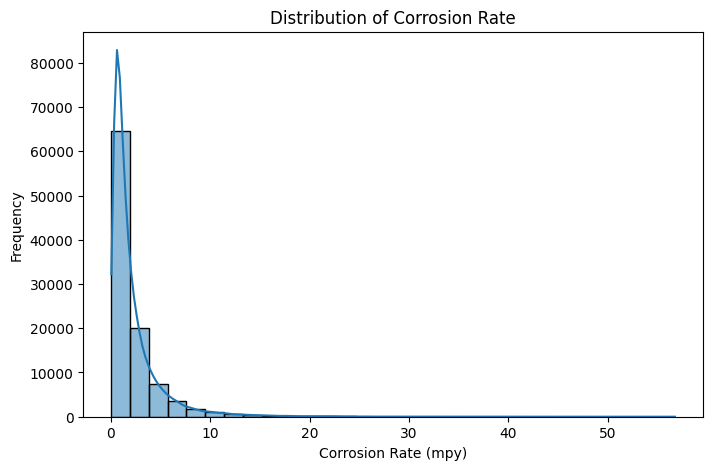

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['corrosion_rate_mpy'],bins=30,kde=True)
plt.title('Distribution of Corrosion Rate')
plt.xlabel('Corrosion Rate (mpy)')
plt.ylabel('Frequency')
plt.show()

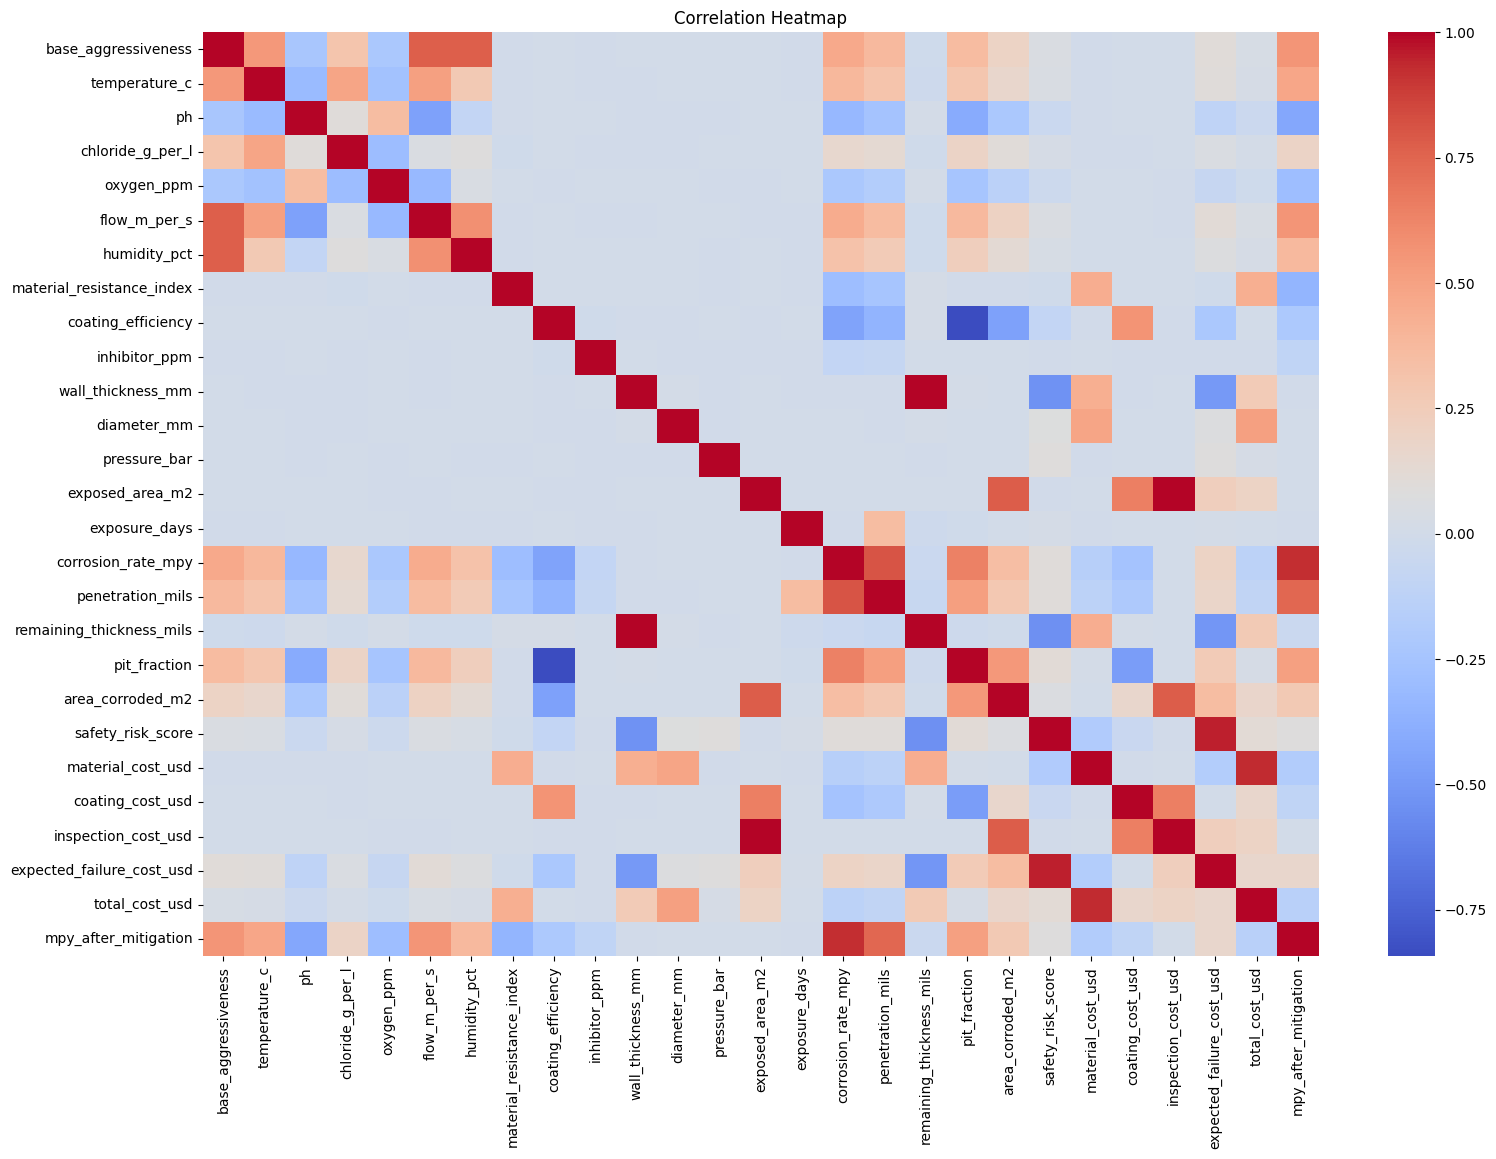

In [13]:
plt.figure(figsize=(18,12))
numeric_df=df.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_df.corr(),cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print(df.isnull().sum())
threshold=len(df)*0.4
df=df.dropna(thresh=threshold,axis=1)

In [ ]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())

In [19]:
categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col]=df[col].fillna("None")

In [20]:
print(df.isnull().sum())

environment                  0
base_aggressiveness          0
temperature_c                0
ph                           0
chloride_g_per_l             0
oxygen_ppm                   0
flow_m_per_s                 0
humidity_pct                 0
material                     0
material_resistance_index    0
coating                      0
coating_efficiency           0
inhibitor_ppm                0
maintenance                  0
wall_thickness_mm            0
diameter_mm                  0
pressure_bar                 0
exposed_area_m2              0
exposure_days                0
corrosion_rate_mpy           0
penetration_mils             0
remaining_thickness_mils     0
pit_fraction                 0
area_corroded_m2             0
safety_risk_score            0
material_cost_usd            0
coating_cost_usd             0
inspection_cost_usd          0
expected_failure_cost_usd    0
total_cost_usd               0
mitigation_barrier           0
mpy_after_mitigation         0
split   

In [49]:
df = pd.get_dummies(df, drop_first=True)

In [55]:
import pandas as pd
df = pd.read_excel('/kaggle/input/datasets/hiteshsankarj/synthetic-corrosion-ml-dataset/synthetic_corrosion_ml_dataset.xlsx')
df = pd.get_dummies(df, drop_first=True)
from sklearn.model_selection import train_test_split
X = df.drop('corrosion_rate_mpy', axis=1)
y = df['corrosion_rate_mpy']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [56]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 50)
X_test shape: (20000, 50)
y_train shape: (80000,)
y_test shape: (20000,)


In [57]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest model trained successfully")

Random Forest model trained successfully


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Both models trained successfully")

In [70]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [71]:
linear_preds = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)
print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2 Score:", linear_r2)

Linear Regression MAE: 0.3973925505369338
Linear Regression RMSE: 0.7103212315290384
Linear Regression R2 Score: 0.9422873693186382


In [73]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


In [74]:
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 0.0066791755000000065
Random Forest RMSE: 0.04737713727353092
Random Forest R2 Score: 0.9997432568237972


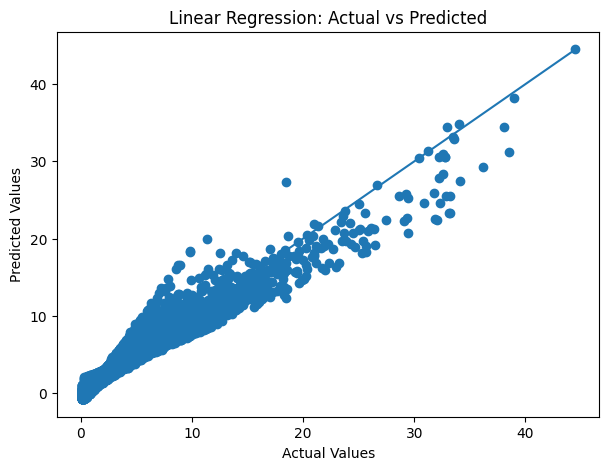

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test, linear_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.show()

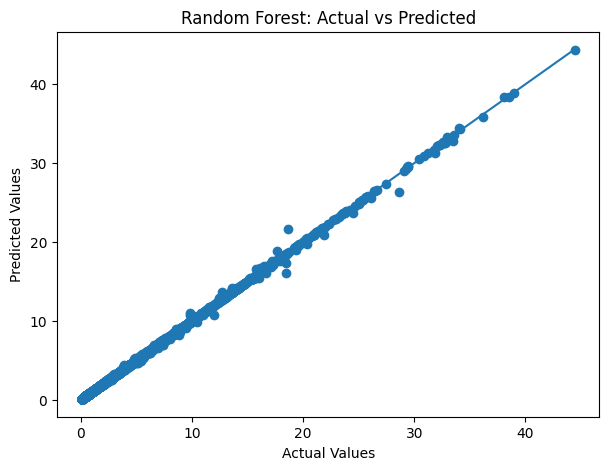

In [76]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.show()

In [80]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

In [83]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [84]:
print(feature_importance.head(10))

                           Feature  Importance
25            mpy_after_mitigation    0.848798
8               coating_efficiency    0.099197
17                    pit_fraction    0.030117
21                coating_cost_usd    0.009772
47  mitigation_barrier_Paint Epoxy    0.006223
42             coating_Paint Epoxy    0.001105
44       coating_Zn-Al Metallizing    0.000838
28       environment_Marine Splash    0.000732
2                               ph    0.000645
43               coating_Wrap Tape    0.000537


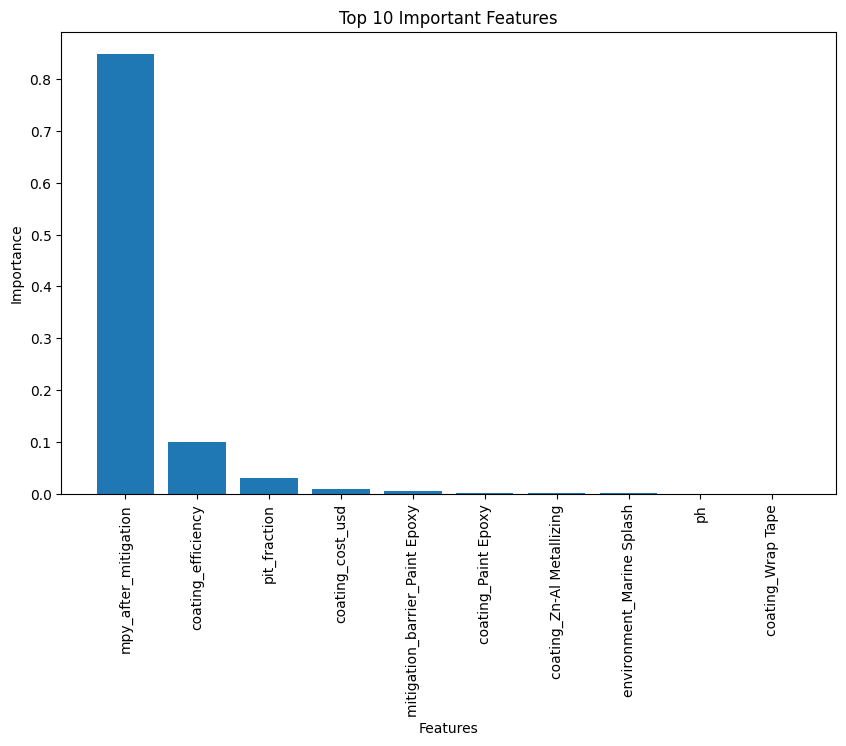

In [85]:
plt.figure(figsize=(10,6))
plt.bar(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

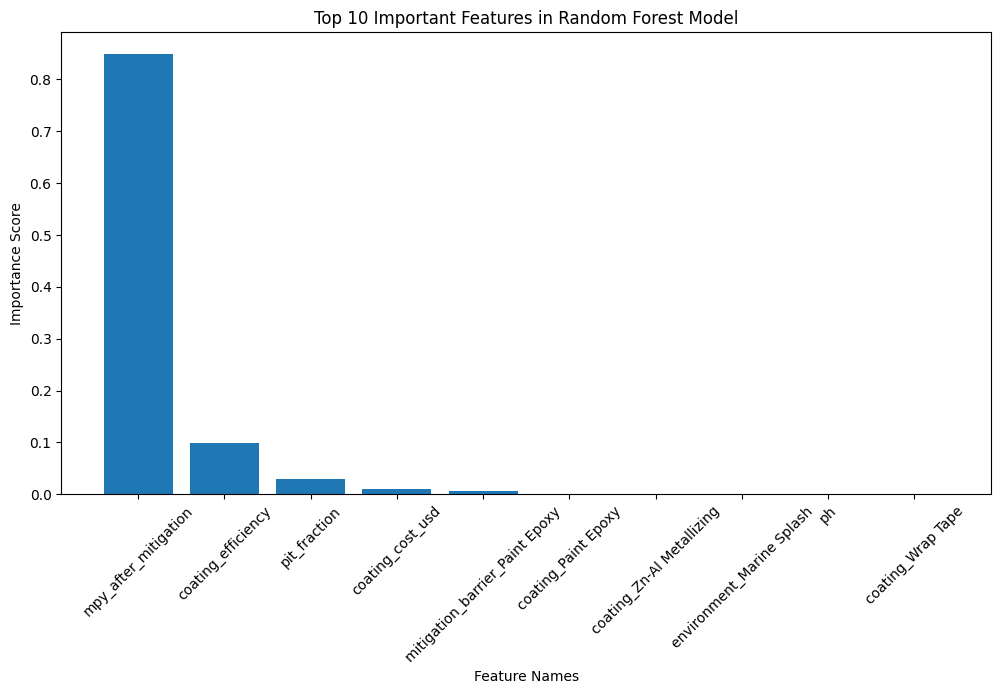

In [87]:
plt.figure(figsize=(12,6))
plt.bar(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)
plt.xticks(rotation=45)
plt.xlabel("Feature Names")
plt.ylabel("Importance Score")
plt.title("Top 10 Important Features in Random Forest Model")
plt.savefig("feature_importance_chart.png", bbox_inches='tight')
plt.show()